<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Document-Distance" data-toc-modified-id="Document-Distance-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Document Distance</a></span><ul class="toc-item"><li><span><a href="#Text-Re-Use" data-toc-modified-id="Text-Re-Use-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Text Re-Use</a></span></li><li><span><a href="#Cosine-Similarity" data-toc-modified-id="Cosine-Similarity-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Cosine Similarity</a></span></li><li><span><a href="#Jensen-Shannon-Divergence" data-toc-modified-id="Jensen-Shannon-Divergence-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Jensen-Shannon Divergence</a></span></li></ul></li><li><span><a href="#Clustering" data-toc-modified-id="Clustering-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Clustering</a></span><ul class="toc-item"><li><span><a href="#K-means-clustering" data-toc-modified-id="K-means-clustering-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>K-means clustering</a></span><ul class="toc-item"><li><span><a href="#Silhouette-Score" data-toc-modified-id="Silhouette-Score-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Silhouette Score</a></span></li></ul></li><li><span><a href="#K-Medoids" data-toc-modified-id="K-Medoids-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>K-Medoids</a></span></li><li><span><a href="#DBSCAN" data-toc-modified-id="DBSCAN-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>DBSCAN</a></span><ul class="toc-item"><li><span><a href="#Hierarchical-DBSCAN" data-toc-modified-id="Hierarchical-DBSCAN-2.3.1"><span class="toc-item-num">2.3.1&nbsp;&nbsp;</span>Hierarchical DBSCAN</a></span></li></ul></li><li><span><a href="#Hierarchical-Clustering" data-toc-modified-id="Hierarchical-Clustering-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Hierarchical Clustering</a></span></li><li><span><a href="#Principal-Component-Analysis" data-toc-modified-id="Principal-Component-Analysis-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Principal Component Analysis</a></span></li></ul></li><li><span><a href="#Latent-Dirichlet-Allocation" data-toc-modified-id="Latent-Dirichlet-Allocation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Latent Dirichlet Allocation</a></span><ul class="toc-item"><li><span><a href="#Singular-Value-Decomposition-(SVD)" data-toc-modified-id="Singular-Value-Decomposition-(SVD)-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Singular Value Decomposition (SVD)</a></span></li><li><span><a href="#Non-negative-Matrix-Factorization-(NMF)" data-toc-modified-id="Non-negative-Matrix-Factorization-(NMF)-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Non-negative Matrix Factorization (NMF)</a></span></li><li><span><a href="#Author-Topic-Model" data-toc-modified-id="Author-Topic-Model-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Author Topic Model</a></span></li></ul></li></ul></div>

Natural Language Processing for Law and Social Science<br>
Elliott Ash, ETH Zurich

In [1]:
# set random seed
import numpy as np
np.random.seed(4)

In [2]:
# If you are using Google Colab, here's the code to load sc_cases_cleaned.pkl from local. 
from google.colab import files
uploaded_1 = files.upload()
uploaded_2 = files.upload()
uploaded_3 = files.upload()

Saving sc_cases_cleaned.pkl to sc_cases_cleaned.pkl


Saving X.pkl to X.pkl


Saving X_tfidf.pkl to X_tfidf.pkl


In [2]:
# Setup
import warnings; warnings.simplefilter('ignore')
%matplotlib inline
import pandas as pd
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
X = pd.read_pickle('X.pkl').toarray()
X_tfidf = pd.read_pickle('X_tfidf.pkl').toarray()

In [3]:
from gensim.utils import simple_preprocess
text0 = ' '.join(simple_preprocess(df['opinion_text'][0]))
text1 = ' '.join(simple_preprocess(df['opinion_text'][1]))

text1[:1000]

'justice stevens delivered the opinion of the court in most of the united states not including california the minimum price paid to dairy farmers producing raw milk is regulated pursuant to federal marketing orders those orders guarantee uniform price for the producers but through pooling mechanisms require the processors of different classes of dairy products to pay different prices thus for example processors of fluid milk pay premium price part of which goes into an equalization pool that provides partial subsidy for cheese manufacturers who pay net price that is lower than the farmers receive seewest lynn creamery inc healy ed ct the california legislature has adopted similar program to regulate the minimum prices paid by california processors to california producers in the cases before us today out of state producers are challenging the of amendment to that program they present us with two questions whether of the federal agriculture improvement and reform act of stat usc uscs exe

# Document Distance

## Text Re-Use

Notes on this implementation of the Smith-Waterman algorithm can be found [here](https://tiefenauer.github.io/blog/smith-waterman/#step-1-scoring-matrix)

In [6]:
import itertools
import numpy as np

def matrix(a, b, match_score=3, gap_cost=2):
    H = np.zeros((len(a) + 1, len(b) + 1), int)

    for i, j in itertools.product(range(1, H.shape[0]), range(1, H.shape[1])):
        match = H[i - 1, j - 1] + (match_score if a[i - 1] == b[j - 1] else - match_score)
        delete = H[i - 1, j] - gap_cost
        insert = H[i, j - 1] - gap_cost
        H[i, j] = max(match, delete, insert, 0)
    return H
def traceback(H, b, b_='', old_i=0):
    # flip H to get index of **last** occurrence of H.max() with np.argmax()
    H_flip = np.flip(np.flip(H, 0), 1)
    i_, j_ = np.unravel_index(H_flip.argmax(), H_flip.shape)
    i, j = np.subtract(H.shape, (i_ + 1, j_ + 1))  # (i, j) are **last** indexes of H.max()
    if H[i, j] == 0:
        return b_, j
    b_ = b[j - 1] + '-' + b_ if old_i - i > 1 else b[j - 1] + b_
    return traceback(H[0:i, 0:j], b, b_, i)
def smith_waterman(a, b, match_score=3, gap_cost=2):
    a, b = a.upper(), b.upper()
    H = matrix(a, b, match_score, gap_cost)
    b_, pos = traceback(H, b)
    return pos, pos + len(b_)

start, end = smith_waterman(text0[:1000], text1[:1000])

In [7]:
text0[start: end]

'justice ginsburg delivered the opinion of the co'

## Cosine Similarity

In [8]:
# compute pair-wise similarities between all documents in corpus"
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X[:100])
print(sim.shape)

sim

(100, 100)


array([[1.        , 0.15048999, 0.14854763, ..., 0.19125305, 0.15697343,
        0.13807391],
       [0.15048999, 1.        , 0.16640306, ..., 0.22500216, 0.13827885,
        0.15798716],
       [0.14854763, 0.16640306, 1.        , ..., 0.13553374, 0.14106085,
        0.26647046],
       ...,
       [0.19125305, 0.22500216, 0.13553374, ..., 1.        , 0.11965342,
        0.11650887],
       [0.15697343, 0.13827885, 0.14106085, ..., 0.11965342, 1.        ,
        0.16104851],
       [0.13807391, 0.15798716, 0.26647046, ..., 0.11650887, 0.16104851,
        1.        ]], shape=(100, 100))

In [9]:
# TF-IDF Similarity
tsim = cosine_similarity(X[:100])
tsim[:3,:3]

array([[1.        , 0.15048999, 0.14854763],
       [0.15048999, 1.        , 0.16640306],
       [0.14854763, 0.16640306, 1.        ]])

## Jensen-Shannon Divergence

In [10]:
from scipy.stats import entropy
def js(p, q):
    p /= p.sum()
    q /= q.sum()
    m = (p + q) / 2
    return (entropy(p, m) + entropy(q, m)) / 2
js(tsim[0],tsim[1])

np.float64(0.052771051140423846)

# Clustering

## K-means clustering

In [11]:
# create 100 clusters of similar documents
from sklearn.cluster import KMeans
num_clusters = 40
km = KMeans(n_clusters=num_clusters)
km.fit(X)
doc_clusters = km.labels_.tolist()

In [12]:
df['cluster'] = doc_clusters
df[df['cluster']==3]['opinion_text']

416    Chief Justice Roberts delivered the opinion of...
747    JUSTICE THOMAS delivered the opinion of the Co...
227    Justice Souter delivered the opinion of the Co...
367    Chief Justice Roberts delivered the opinion of...
674    JUSTICE STEVENS delivered the opinion of the C...
756    JUSTICE STEVENS delivered the opinion of the C...
203    JUSTICE O'CONNOR delivered the opinion of the ...
759    CHIEF JUSTICE REHNQUIST delivered the opinion ...
742    JUSTICE STEVENS delivered the opinion of the C...
455    Justice Alito delivered the opinion of the Cou...
618    JUSTICE KENNEDY delivered the opinion of the C...
220    Justice Stevens delivered the opinion of the C...
606    Chief Justice Rehnquist announced the judgment...
712    JUSTICE THOMAS delivered the opinion of the Co...
532    Justice Ginsburg delivered the opinion of the ...
607    Justice O'Connor delivered the opinion of the ...
511    Justice Kennedy delivered the opinion of the C...
Name: opinion_text, dtype: obje

### Silhouette Score

Choose the optimal number of clusters. 

In [13]:
from sklearn.metrics import silhouette_score
silhouette_score(X, km.labels_)

0.03703714735502547

In [14]:
sil_scores = []
for n in range(2, num_clusters):
    km = KMeans(n_clusters=n)
    km.fit(X)
    sil_scores.append(silhouette_score(X, km.labels_))

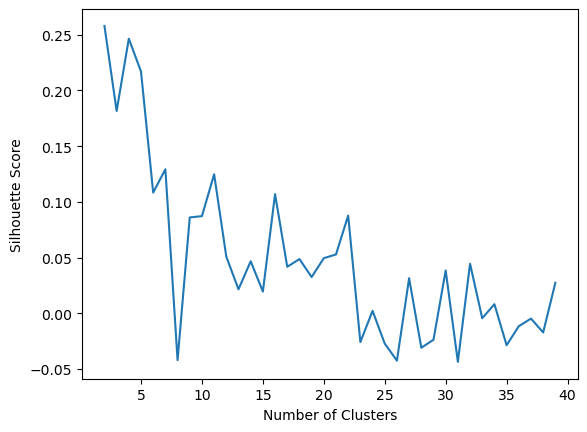

In [15]:
import matplotlib.pyplot as plt 
plt.plot(range(2, num_clusters), sil_scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [16]:
opt_sil_score = max(sil_scores[5:20])
sil_scores.index(opt_sil_score)
opt_num_cluster = range(2, num_clusters)[sil_scores.index(opt_sil_score)]
print('The optimal number of clusters is %s' %opt_num_cluster)

The optimal number of clusters is 7


In [17]:
km = KMeans(n_clusters=opt_num_cluster)
km.fit(X)
doc_clusters = km.labels_.tolist()

df['cluster_mean'] = doc_clusters
df[df['cluster_mean']==1]['opinion_text']


345    Chief Justice Roberts delivered the opinion of...
696    JUSTICE O'CONNOR delivered the opinion of the ...
549    JUSTICE STEVENS delivered the opinion of the C...
790    JUSTICE O'CONNOR delivered the opinion of the ...
73     Justice Thomas delivered the opinion of the Co...
                             ...                        
208    Justice Kennedy announced the judgment of the ...
81     Justice Kennedy delivered the opinion of the C...
253    JUSTICE GINSBURG delivered the opinion of the ...
245    Justice Souter delivered the opinion of the Co...
438    CHIEF JUSTICE Roberts delivered the opinion of...
Name: opinion_text, Length: 533, dtype: object

## K-Medoids

In [23]:
!pip install kmedoids
import kmedoids
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X, metric='euclidean')
km = kmedoids.KMedoids(opt_num_cluster, method='fasterpam')
km.fit(D)
doc_clusters = km.labels_.tolist()

df['cluster_med'] = doc_clusters
df[df['cluster_med']==1]['opinion_text']




656    JUSTICE GINSBURG delivered the opinion of the ...
790    JUSTICE O'CONNOR delivered the opinion of the ...
229    Justice Kennedy delivered the opinion of the C...
14     Chief Justice Roberts delivered the opinion of...
583    JUSTICE KENNEDY delivered the opinion of the C...
                             ...                        
70     Justice O'Connor delivered the opinion of the ...
210    Justice Souter delivered the opinion of the Co...
522    Justice Ginsburg delivered the opinion of the ...
590    Justice Stevens announced the judgment of the ...
500    Chief Justice Roberts delivered the opinion of...
Name: opinion_text, Length: 134, dtype: object

## DBSCAN

In [24]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.95, min_samples=5)
dbscan.fit(X_tfidf)
db_clusters = dbscan.labels_

df['cluster_db'] = db_clusters
df[df['cluster_db']==1]['opinion_text']

656    JUSTICE GINSBURG delivered the opinion of the ...
384    Justice Stevens delivered the opinion of the C...
185    Justice Kennedy delivered the opinion of the C...
609    Justice O'Connor delivered the opinion of the ...
14     Chief Justice Roberts delivered the opinion of...
                             ...                        
444    Justice Ginsburg delivered the opinion of the ...
55     JUSTICE SCALIA announced the judgment of the C...
210    Justice Souter delivered the opinion of the Co...
710    JUSTICE KENNEDY announced the judgment of the ...
50     JUSTICE STEVENS announced the judgment of the ...
Name: opinion_text, Length: 104, dtype: object

### Hierarchical DBSCAN

Automatically chooses epsilon, performing DBSCAN over various epsilon values e returns the result that gives the best stability over epsilon. For reference see [here](https://github.com/scikit-learn-contrib/hdbscan/).

In [26]:
!pip install hdbscan

from hdbscan import HDBSCAN

hdbscan = HDBSCAN(min_cluster_size=5)
hdbscan.fit(X_tfidf)
hdb_clusters = hdbscan.labels_

df['cluster_hdb'] = hdb_clusters
df[df['cluster_hdb']==1]['opinion_text']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 20.3 MB/s  0:00:00


458    Justice Stevens delivered the opinion of the C...
615    JUSTICE KENNEDY delivered the opinion of the C...
540    JUSTICE STEVENS delivered the opinion of the C...
617    JUSTICE O'CONNOR delivered the opinion of the ...
469    Justice Scalia delivered the opinion of the Co...
199    Justice Stevens delivered the opinion of the C...
212    Justice Scalia delivered the opinion of the Co...
505    Justice Kennedy delivered the opinion of the C...
808    JUSTICE SCALIA delivered the opinion of the Co...
596    JUSTICE BREYER delivered the opinion of the Co...
326    Justice Souter delivered the opinion of the Co...
385    Justice Scalia delivered the opinion of the Co...
676    JUSTICE O'CONNOR delivered the opinion of the ...
96     Justice Ginsburg delivered the opinion of the ...
327    Justice Stevens delivered the opinion of the C...
364    Justice Alito delivered the opinion of the Cou...
Name: opinion_text, dtype: object

## Hierarchical Clustering

In [28]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=opt_num_cluster, metric='euclidean', linkage='ward')
cluster.fit_predict(X)

clusters = cluster.labels_


df['cluster_hie'] = clusters
df[df['cluster_hie']==1]['opinion_text']


345    Chief Justice Roberts delivered the opinion of...
696    JUSTICE O'CONNOR delivered the opinion of the ...
549    JUSTICE STEVENS delivered the opinion of the C...
790    JUSTICE O'CONNOR delivered the opinion of the ...
73     Justice Thomas delivered the opinion of the Co...
                             ...                        
208    Justice Kennedy announced the judgment of the ...
81     Justice Kennedy delivered the opinion of the C...
253    JUSTICE GINSBURG delivered the opinion of the ...
245    Justice Souter delivered the opinion of the Co...
438    CHIEF JUSTICE Roberts delivered the opinion of...
Name: opinion_text, Length: 589, dtype: object

## Principal Component Analysis

In [29]:
#%% Principal Components
from sklearn.decomposition import PCA
pca = PCA(n_components=3,svd_solver='randomized')
Xpca = pca.fit_transform(X)
pca.explained_variance_ratio_

array([0.06008335, 0.03858286, 0.03146095])

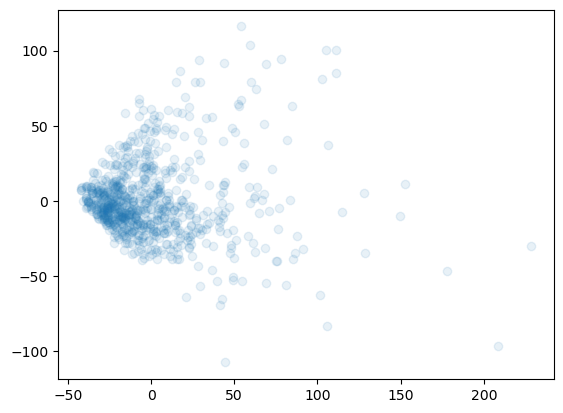

In [30]:
#%% PCA Viz
plt.scatter(Xpca[:,0],Xpca[:,1], alpha=.1)
plt.show()

In [31]:
#%% PCA 3D Viz
from mpl_toolkits.mplot3d import Axes3D
Axes3D(plt.figure()).scatter(Xpca[:,0],Xpca[:,1], Xpca[:,2], alpha=.1)
plt.show()

<Figure size 640x480 with 0 Axes>

In [32]:
#%% make components to explain 95% of variance
pca = PCA(n_components=.95)
X95 = pca.fit_transform(X)
pca.n_components_

np.int64(304)

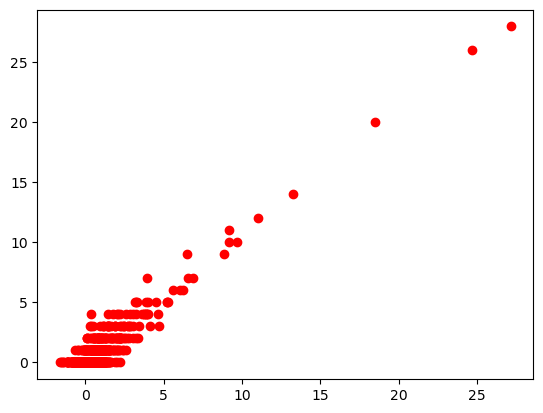

In [33]:
#%% PCA Inverse Transform
Xrestore = pca.inverse_transform(X95)
plt.plot(Xrestore[0],X[0],'ro')

In [34]:
#%% Incremental PCA
X_mm = np.memmap('X.pkl',shape=(32567, 525))

from sklearn.decomposition import IncrementalPCA
inc_pca = IncrementalPCA(n_components=100, batch_size=1000)
inc_pca.fit(X_mm)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",100
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",1000


In [35]:
#%% PC Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
Y = df['log_cite_count']
lin_reg = LinearRegression()
scores = cross_val_score(lin_reg,
                         X95[:,:10],
                         Y) 
scores.mean()

np.float64(0.19088429612613247)

In [42]:
#%% MDS, Isomap, and T-SNE
from sklearn.manifold import MDS, Isomap, TSNE
mds = MDS(n_components=2)
Xmds = mds.fit_transform(X[:500,:200])
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(Xmds[:,0], Xmds[:,1], alpha=.3)
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
#%% Isomap
iso = Isomap(n_components=2)
Xiso = iso.fit_transform(X[:500,:200])
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(Xiso[:,0], Xiso[:,1], alpha=.3)
plt.show()

In [40]:
#%% t-SNE
tsne = TSNE(n_components=2, max_iter=250)
Xtsne = tsne.fit_transform(X[:500,:200])
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(Xtsne[:,0], Xtsne[:,1], alpha=.3)
plt.show()

<Figure size 640x480 with 0 Axes>

# Latent Dirichlet Allocation

For further reference see the material from topic [modeling with gensim](https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/).

In [43]:
# clean document
from gensim.utils import simple_preprocess
import spacy
from spacy.tokenizer import Tokenizer
from tqdm import tqdm as tq
nlp = spacy.load('en_core_web_sm')
# this is faster and we don't need the whole grammatical parse analysis

def tokenize(x, nlp):
    # lemmatize and lowercase without stopwords, punctuation and numbers
    return [w.lemma_.lower() for w in nlp(x) if not w.is_stop and not w.is_punct and not w.is_digit and len(w) > 2]

# split into paragraphs
doc_clean = []
for doc in tq(df['opinion_text'][:100]):
    # split by paragraph
    for paragraph in doc.split("\n\n"):
        doc_clean.append(tokenize(paragraph, nlp))
print (doc_clean[:2])


# randomize document order
from random import shuffle
shuffle(doc_clean)

# creating the term dictionary
from gensim import corpora
dictionary = corpora.Dictionary(doc_clean)
# filter extremes, drop all words appearing in less than 10 paragraphs and all words appearing in at least every third paragraph
dictionary.filter_extremes(no_below=10, no_above=0.33, keep_n=1000)
print (len(dictionary))


# creating the document-term matrix
doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]

# train LDA with 10 topics and print
from gensim.models.ldamodel import LdaModel
lda = LdaModel(doc_term_matrix, num_topics=10, 
               id2word = dictionary, passes=3)
lda.show_topics(formatted=True)

100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


[['chief', 'justice', 'roberts', 'deliver', 'opinion', 'court'], ['bad', 'thing', 'happen', 'fail', 'pay', 'federal', 'income', 'taxis', 'interest', 'accrue', 'unpaid', 'take', 'internal', 'revenue', 'service', 'irs', 'determine', 'taxis', 'pay', 'section', '6404(e)(1', 'internal', 'revenue', 'code', 'permit', 'secretary', 'treasury', 'abate', 'interest', 'forgive', 'partially', 'assessment', 'interest', 'deficiency', 'attributable', 'unreasonable', 'error', 'delay', 'irs', 'section', '6404(h', 'allow', 'judicial', 'review', 'secretary', 'decision', 'grant', 'relief', 'question', 'present', 'case', 'review', 'obtain', 'tax', 'court', 'secure', 'district', 'court', 'court', 'federal', 'claims', 'hold', 'tax', 'court', 'provide', 'exclusive', 'forum', 'judicial', 'review', 'refusal', 'abate', 'interest', '6404(e)(1', 'affirm']]
1000


[(0,
  '0.089*"information" + 0.059*"know" + 0.034*"task" + 0.021*"state" + 0.020*"allegation" + 0.019*"device" + 0.018*"provide" + 0.018*"obligation" + 0.017*"michigan" + 0.016*"owner"'),
 (1,
  '0.021*"act" + 0.018*"state" + 0.016*"congress" + 0.013*"statute" + 0.013*"law" + 0.011*"states" + 0.011*"united" + 0.011*"u.s." + 0.008*"term" + 0.008*"government"'),
 (2,
  '0.070*"rule" + 0.061*"deal" + 0.057*"know" + 0.055*"information" + 0.036*"limitation" + 0.036*"agency" + 0.034*"time" + 0.034*"change" + 0.034*"liability" + 0.033*"practice"'),
 (3,
  '0.079*"fda" + 0.064*"pre" + 0.041*"emption" + 0.038*"find" + 0.038*"failure" + 0.038*"argument" + 0.037*"conflict" + 0.035*"evidence" + 0.022*"order" + 0.022*"warning"'),
 (4,
  '0.051*"opinion" + 0.049*"justice" + 0.041*"deliver" + 0.026*"evidence" + 0.022*"jury" + 0.014*"trial" + 0.014*"id." + 0.012*"state" + 0.011*"mental" + 0.010*"factor"'),
 (5,
  '0.017*"u.s." + 0.016*"counsel" + 0.014*"district" + 0.012*"case" + 0.011*"plan" + 0.010

In [44]:
# to get the topic proportions for a document, use
# the corresponding row from the document-term matrix.
lda[doc_term_matrix[1]]

[(0, np.float32(0.09999999)),
 (1, np.float32(0.09999999)),
 (2, np.float32(0.09999999)),
 (3, np.float32(0.09999999)),
 (4, np.float32(0.09999999)),
 (5, np.float32(0.09999999)),
 (6, np.float32(0.09999999)),
 (7, np.float32(0.09999999)),
 (8, np.float32(0.09999999)),
 (9, np.float32(0.09999999))]

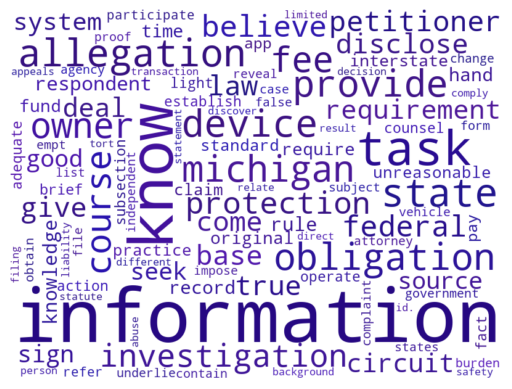

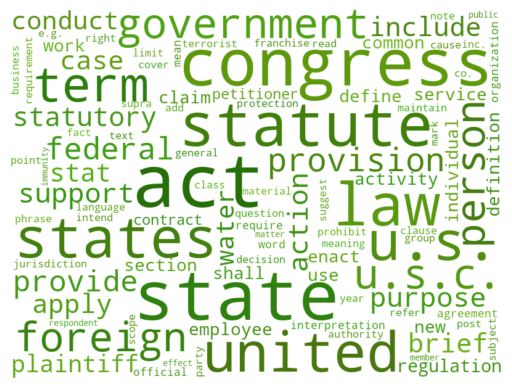

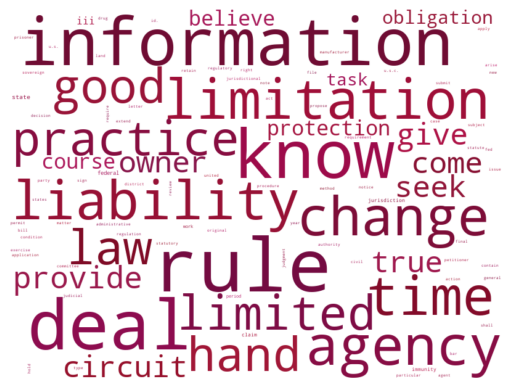

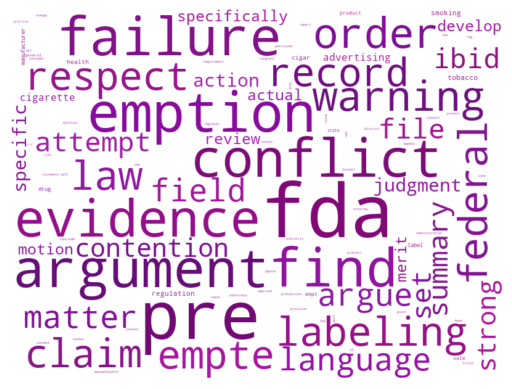

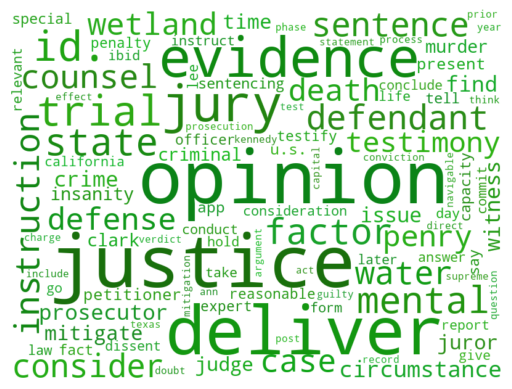

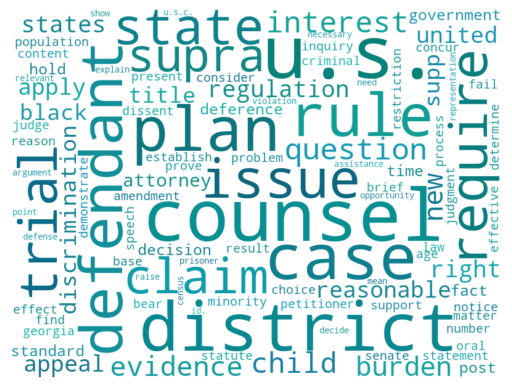

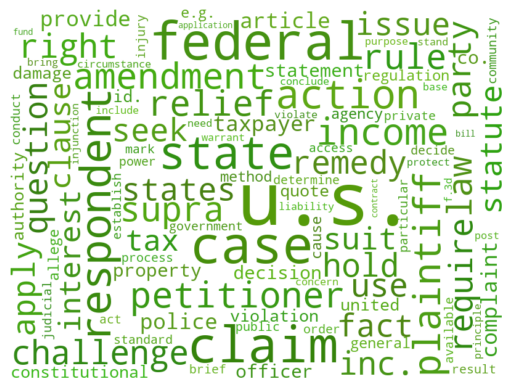

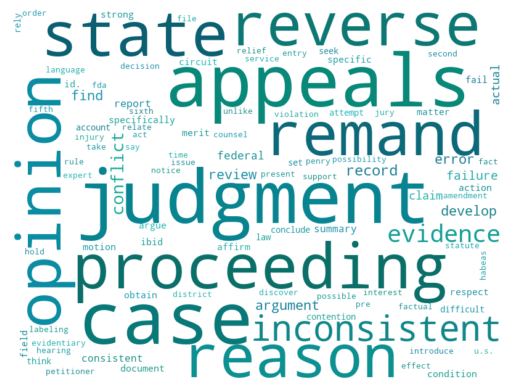

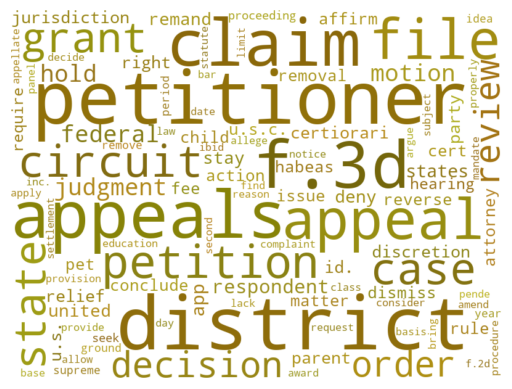

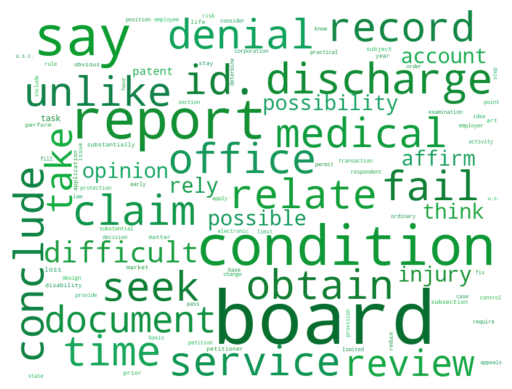

In [45]:
###
# LDA Word Clouds
###

from numpy.random import randint
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# make directory if not exists
from os import mkdir
try:
    mkdir('lda')
except:
    pass

# make word clouds for the topics
for i,weights in lda.show_topics(num_topics=-1,
                                 num_words=100,
                                 formatted=False):
    
    #logweights = [w[0], np.log(w[1]) for w in weights]
    maincol = randint(0,360)
    def colorfunc(word=None, font_size=None, 
                  position=None, orientation=None, 
                  font_path=None, random_state=None):   
        color = randint(maincol-10, maincol+10)
        if color < 0:
            color = 360 + color
        return "hsl(%d, %d%%, %d%%)" % (color,randint(65, 75)+font_size / 7, randint(35, 45)-font_size / 10)   

    
    wordcloud = WordCloud(background_color="white", 
                          ranks_only=False, 
                          max_font_size=120,
                          color_func=colorfunc,
                          height=600,width=800).generate_from_frequencies(dict(weights))

    plt.clf()
    plt.imshow(wordcloud,interpolation="bilinear")
    plt.axis("off")
    plt.show()


In [47]:
# pyLDAvis, for more details, refer to https://github.com/bmabey/pyLDAvis
!pip install pyLDAvis
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
pyLDAvis.gensim.prepare(lda, doc_term_matrix, dictionary)

  Using cached funcy-2.0-py2.py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.3 MB/s  0:00:00
Using cached funcy-2.0-py2.py3-none-any.whl (30 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pyLDAvis]2/3 [pyLDAvis]


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.151088 -0.081994       1        1  25.758538
1     -0.165399 -0.077273       2        1  25.723382
5     -0.147102 -0.103095       3        1  15.693681
8     -0.075586 -0.109494       4        1  14.089244
4     -0.058856 -0.100043       5        1  10.495572
3      0.273292 -0.071754       6        1   2.198072
0     -0.134933  0.177255       7        1   2.127608
9      0.299423  0.084664       8        1   1.381209
7      0.188867 -0.129933       9        1   1.292104
2     -0.028620  0.411665      10        1   1.240590, topic_info=             Term         Freq        Total Category  logprob  loglift
209         state  2056.000000  2056.000000  Default  30.0000  30.0000
1            case  1661.000000  1661.000000  Default  29.0000  29.0000
264       opinion  1194.000000  1194.000000  Default  28.0000  28.0000
103       appeals   788.000000   788.000000  Default  27.0000  27.0000
39           rule   851.000000   851.000000  Default  26.0000  26.0000
..            ...          ...          ...      ...      ...      ...
859          bill     0.885190   115.051791  Topic10  -7.7074  -0.4778
635          work     1.089197   189.483409  Topic10  -7.5001  -0.7693
134  jurisdiction     1.324664   359.368445  Topic10  -7.3043  -1.2136
209         state     1.867618  2056.482592  Topic10  -6.9608  -2.6145
12        federal     1.674524  1227.116451  Topic10  -7.0700  -2.2073

[512 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
817       1  0.828833  access
817       2  0.007145  access
817       3  0.014290  access
817       4  0.135757  access
817       5  0.007145  access
...     ...       ...     ...
635       5  0.073885    work
635      10  0.005278    work
826       1  0.066837    writ
826       3  0.066837    writ
826       4  0.868879    writ

[1924 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 2, 6, 9, 5, 4, 1, 10, 8, 3])

Using Mallet to calculate coherence scores for different number of topics to automatically determine the best number of topics


In [50]:
!curl -O http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
!unzip mallet-2.0.8.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   233  100   233    0     0    412      0 --:--:-- --:--:-- --:--:--   415
Archive:  mallet-2.0.8.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of mallet-2.0.8.zip or
        mallet-2.0.8.zip.zip, and cannot find mallet-2.0.8.zip.ZIP, period.


In [53]:
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import warnings
warnings.filterwarnings("ignore")

scores = []
for num_topics in range(2, 20, 2):
    print(num_topics)
    lda = LdaModel(doc_term_matrix, num_topics=num_topics, id2word=dictionary, passes=3)
    coherence = CoherenceModel(model=lda, texts=doc_clean, corpus=doc_term_matrix, dictionary=dictionary, coherence='c_v')
    scores.append((num_topics, coherence.get_coherence()))
pd.DataFrame(scores, columns=["Number of Topics", "Coherence Scores"])


2
4
6
8
10
12
14
16
18


,Number of Topics,Coherence Scores
0,2,0.268843
1,4,0.337531
2,6,0.328175
3,8,0.363057
4,10,0.329259
5,12,0.332391
6,14,0.352382
7,16,0.321218
8,18,0.370755


## Singular Value Decomposition (SVD)

For further reference for this and the following section see [here](https://github.com/fastai/course-nlp/blob/219d0c217bd83339e21471d31cd787e86d6ec0a0/2-svd-nmf-topic-modeling.ipynb).

In [54]:
upload_4 = files.upload()

NameError: name 'files' is not defined

In [55]:
from scipy import linalg

X = pd.read_pickle('X.pkl').todense()
vec = pd.read_pickle('vec-3grams-1.pkl')
vocab = np.array(vec.get_feature_names_out())
vocab[400:500]


array(['department', 'described', 'designed', 'despite', 'detention',
       'determination', 'determine', 'determined', 'determining',
       'different', 'difficult', 'direct', 'directly', 'discharge',
       'discretion', 'discrimination', 'dismissed', 'dispute', 'dissent',
       'dissenting', 'distinction', 'district', 'district court',
       'districts', 'doctrine', 'domestic', 'doubt', 'drug', 'drugs',
       'duty', 'earlier', 'ed supp', 'education', 'effect', 'effective',
       'election', 'element', 'elements', 'emphasis', 'emphasis added',
       'employee', 'employees', 'employer', 'employment', 'enacted',
       'end', 'enforce', 'enforcement', 'entered', 'entitled', 'epa',
       'equal', 'equitable', 'erisa', 'error', 'establish', 'established',
       'et', 'et seq', 'event', 'evidence', 'ex', 'example', 'exception',
       'executive', 'exercise', 'existing', 'explained', 'express',
       'expressly', 'extent', 'fact', 'factor', 'factors', 'facts',
       'factual',

In [56]:
U, s, Vh = linalg.svd(X, full_matrices=False)
print(U.shape, s.shape, Vh.shape)

(768, 768) (768,) (768, 1000)


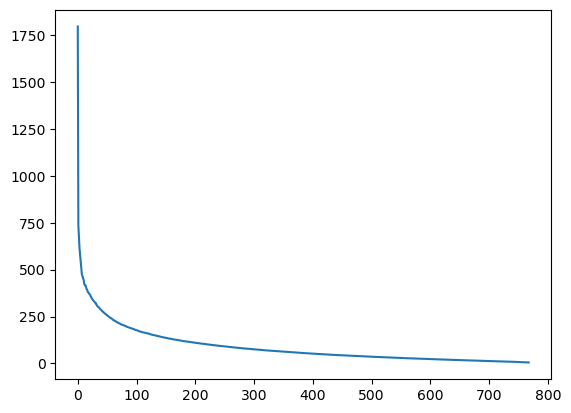

In [57]:
plt.plot(s)

In [58]:
num_top_words=8

def show_topics(a):
    top_words = lambda t: [vocab[i] for i in np.argsort(t)[:-num_top_words-1:-1]]
    topic_words = ([top_words(t) for t in a])
    return [' '.join(t) for t in topic_words]

show_topics(Vh[:10])

['state act district congress rule statute government courts',
 'act congress government action statute agency jurisdiction commission',
 'state state law commerce pre property state court immunity districts',
 'district district court jurisdiction claims claim rule courts habeas',
 'district right amendment school rights minority speech districts',
 'right military jurisdiction habeas war courts rights amendment',
 'district military war congress death habeas commission sentence',
 'right act plan damages action rights claims death',
 'commission tax rate party military judge war plan',
 'counsel rate service evidence right cost act epa']

## Non-negative Matrix Factorization (NMF) 

In [59]:
from sklearn import decomposition

clf = decomposition.NMF(n_components=10, random_state=1)
X = np.array(X)
W1 = clf.fit_transform(X)
H1 = clf.components_

show_topics(H1)

['district minority districts plan district court voting majority political',
 'trial evidence counsel rule defendant petitioner judge jury',
 'state new state court courts state law tax claim clause',
 'death sentence penalty jury sentencing death penalty crime offense',
 'action claims claim jurisdiction rule parties district district court',
 'right amendment rights bear second state constitutional clause',
 'military war habeas commission government jurisdiction courts cases',
 'school public government religious speech schools program private',
 'act congress statute agency authority regulations use health',
 'rate service cost rates commission elements local market']

## Author Topic Model

In [60]:
from gensim.models import AuthorTopicModel
from gensim.test.utils import temporary_file

df = df.reset_index()
df['id'] = df.index
author2doc = df[:100][['authorship','id']]
author2doc = author2doc.groupby('authorship').apply(lambda x: list(x['id'])).to_dict()
author2doc

{'ALITO': [57, 69, 74, 90],
 'BREYER': [26, 39, 66, 68, 75, 84, 95],
 'GINSBURG': [2, 10, 38, 49, 92, 98],
 'KENNEDY': [8, 9, 11, 20, 28, 31, 34, 42, 44, 45, 53, 59, 76, 79, 86],
 "O'CONNOR": [1, 4, 6, 12, 14, 18, 25, 29, 40, 52, 55, 56, 65, 70, 77, 82],
 'REHNQUIST': [30, 37, 63, 87],
 'ROBERTS': [0, 13, 17, 48, 61, 71, 85, 89, 97],
 'SCALIA': [27, 32, 35, 36, 43, 47, 50, 54, 60, 67, 78, 81, 99],
 'SOUTER': [16, 19, 24, 46, 62, 73, 88, 91, 94],
 'STEVENS': [3, 7, 15, 21, 23, 41, 51, 58, 64, 72, 83, 93],
 'THOMAS': [5, 22, 33, 80, 96]}

In [61]:
model = AuthorTopicModel(
        doc_term_matrix, author2doc=author2doc, id2word=dictionary, num_topics=10)

# For each author list topic distribution
author_vecs = [model.get_author_topics(author) for author in model.id2author.values()]
author_vecs[:2]

[[(4, np.float64(0.08172519260059066)),
  (6, np.float64(0.032657232755654776)),
  (7, np.float64(0.4739323855444106)),
  (9, np.float64(0.40591804676697985))],
 [(0, np.float64(0.14248863168959217)),
  (7, np.float64(0.5466963326941255)),
  (8, np.float64(0.30183811948322276))]]